In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import numpy as np
import math


In [68]:
BASE_DIR = 'D:/Leonardo/UDESA - CENTRO Cuantitativo/EPU ARG/src'
save_results_dir = Path(BASE_DIR).parent / "data" / "results" / "subcategories"
results_file = save_results_dir / "all_subcategories_compare.xlsx"

df = pd.read_excel(results_file, sheet_name="Data")
df.set_index('fecha', inplace=True)

In [69]:
ghirelli = pd.read_excel(results_file, sheet_name="benchmark")
ghirelli.set_index('fecha', inplace=True)
ghirelli = ghirelli.reindex(df.index).ffill()

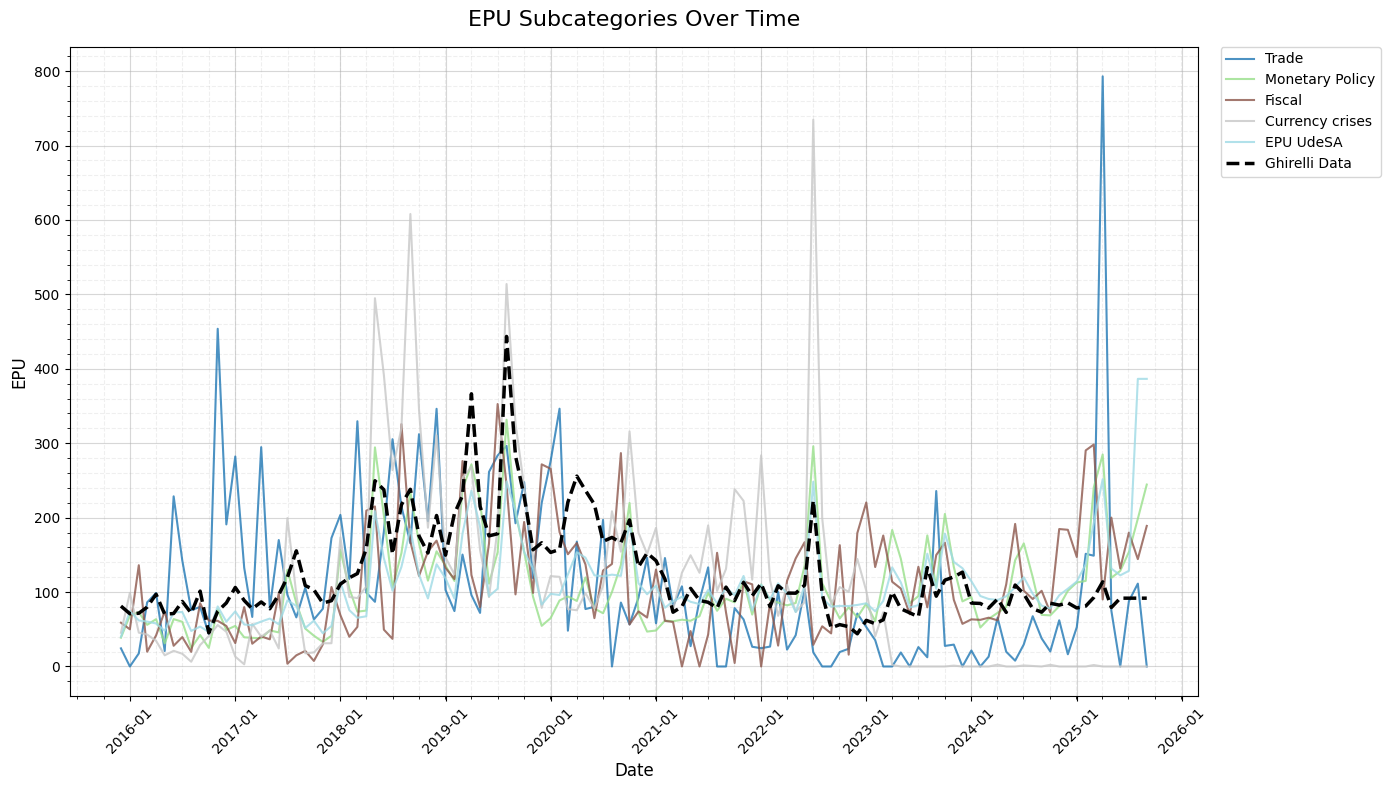

In [70]:
plt.style.use('seaborn-v0_8-deep') 
plt.figure(figsize=(14, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(df.columns)))
for idx, column in enumerate(df.columns):
    plt.plot(df.index, df[column], label=column, color=colors[idx], alpha=0.8, linewidth=1.5)

plt.plot(df.index, ghirelli, label='Ghirelli Data', linestyle='--', color='black', linewidth=2.5, alpha=1)

plt.title('EPU Subcategories Over Time', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('EPU', fontsize=12)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.grid(True, which='minor', linestyle='--', alpha=0.2)
plt.minorticks_on()

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10, frameon=True, borderaxespad=0)

plt.tight_layout()
plt.show()

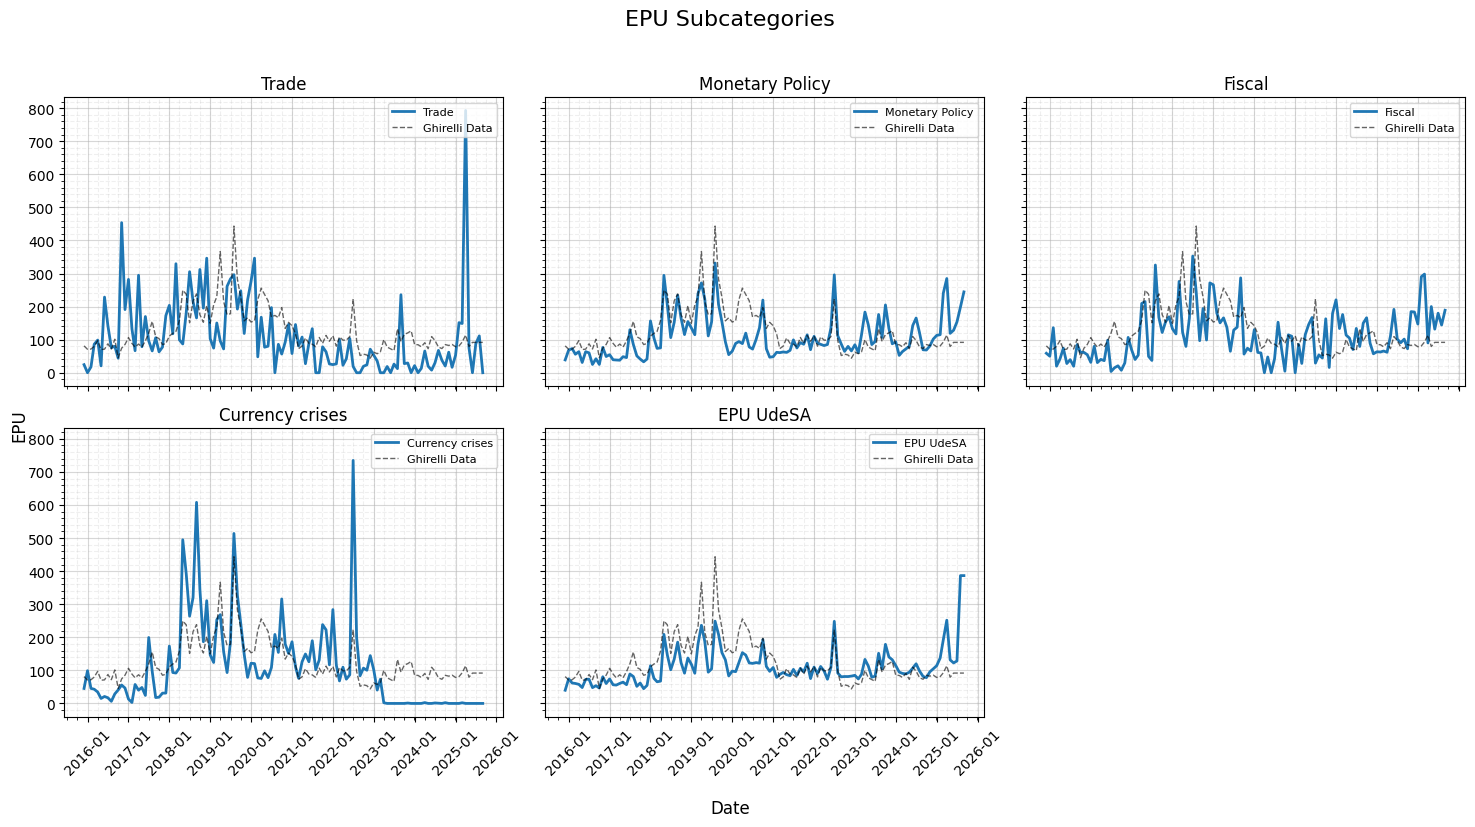

In [71]:
plt.style.use('seaborn-v0_8-deep')


n_cols = len(df.columns)
n_cols_per_row = math.ceil(math.sqrt(n_cols)) 
n_rows = math.ceil(n_cols / n_cols_per_row)


fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(5 * n_cols_per_row, 4 * n_rows), sharex=True, sharey=True)


axes = np.array(axes).flatten()
color_df = plt.cm.tab10(0)  
color_ghirelli = 'black'     


for idx, column in enumerate(df.columns):
    ax = axes[idx]
    ax.plot(df.index, df[column], label=column, color=color_df, linewidth=2, alpha=1)
    ax.plot(df.index, ghirelli, label='Ghirelli Data', color=color_ghirelli, linestyle='--', linewidth=1, alpha=0.6)
    
    ax.set_title(column, fontsize=12)
    
    ax.grid(True, which='major', linestyle='-', alpha=0.5)
    ax.grid(True, which='minor', linestyle='--', alpha=0.2)
    ax.minorticks_on()
    
    ax.legend(fontsize=8, loc='upper right')
    
for idx in range(len(df.columns), len(axes)):
    fig.delaxes(axes[idx])

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45)

fig.supxlabel('Date', fontsize=12)
fig.supylabel('EPU', fontsize=12)

fig.suptitle('EPU Subcategories', fontsize=16, y=1.02)

plt.tight_layout()

plt.show()

In [72]:
save_results_dir = Path(BASE_DIR).parent / "data" / "results"
proportion_file = save_results_dir / "epu_analysis_results_udesa_jp.xlsx"
df_proportion = pd.read_excel(proportion_file, sheet_name="Positive_Proportion")
df_proportion.set_index('fecha', inplace=True)
df_proportion = df_proportion.reindex(df.index).ffill()

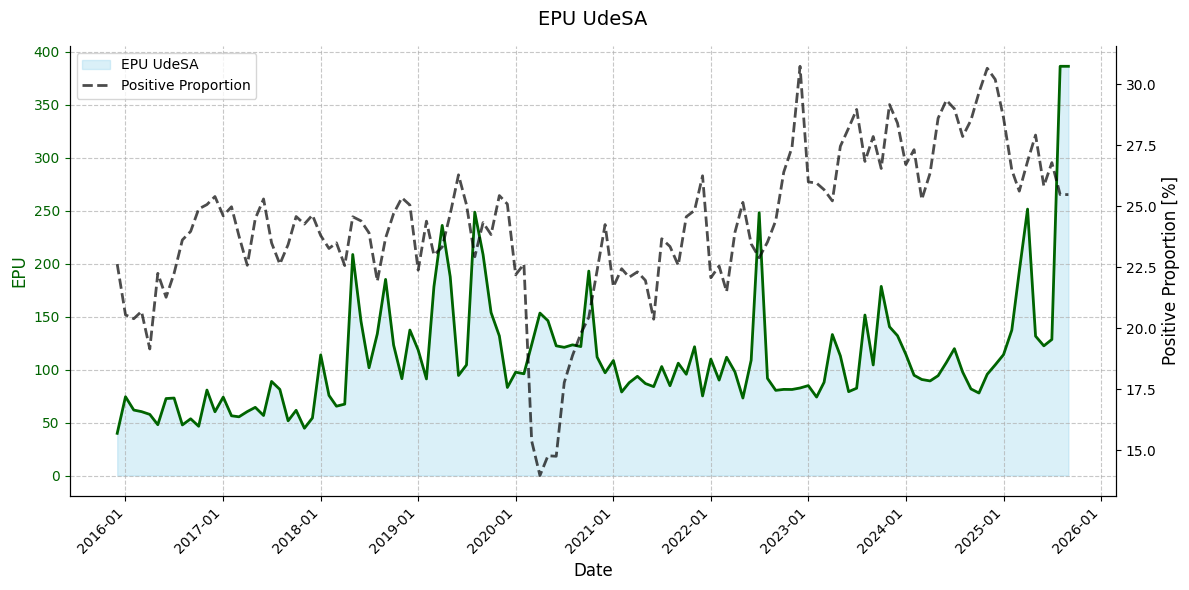

In [74]:
right_axis_color = 'darkgreen'
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(12, 6))

ax1 = plt.gca()
ax1.fill_between(df.index, df["EPU UdeSA"], alpha=0.3, color='skyblue', label="EPU UdeSA")
ax1.plot(df.index, df["EPU UdeSA"], color=right_axis_color, linewidth=2)

ax2 = ax1.twinx()
ax2.plot(df_proportion.index, round(100*df_proportion["positive_proportion"], 2), label='Positive Proportion', linestyle='--', color='black', alpha=0.7, linewidth=2)

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('EPU', fontsize=12, color=right_axis_color)
ax2.set_ylabel('Positive Proportion [%]', fontsize=12, color='black')

plt.title('EPU UdeSA', fontsize=14, pad=15)

ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

ax1.grid(True, linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(axis='y', colors=right_axis_color)
ax2.tick_params(axis='y', colors='black')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()